# PHYS3116 Group Assessment

In [ ]:
# Libraries and LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

# Data extraction
harris = pd.read_csv(r"C:\Users\HassanNoun\OneDrive - UNSW\Desktop\PHYS3116\Group Assessment\GitHubClone_PHYS3116\PHYS3116_Team\HarrisPartI.csv")
vberg = pd.read_csv(r"C:\Users\HassanNoun\OneDrive - UNSW\Desktop\PHYS3116\Group Assessment\GitHubClone_PHYS3116\PHYS3116_Team\vandenBerg_table2.csv")

# Extracting key spatial coordinates
R = harris["R_gc"]
X = harris["X"]
Y = harris["Y"]
Z = harris["Z"]
names = harris["ID"]

ages_v = vberg["Age"]
feh_v  = vberg["FeH"]

## Identifying Clusters with Dynamical Data

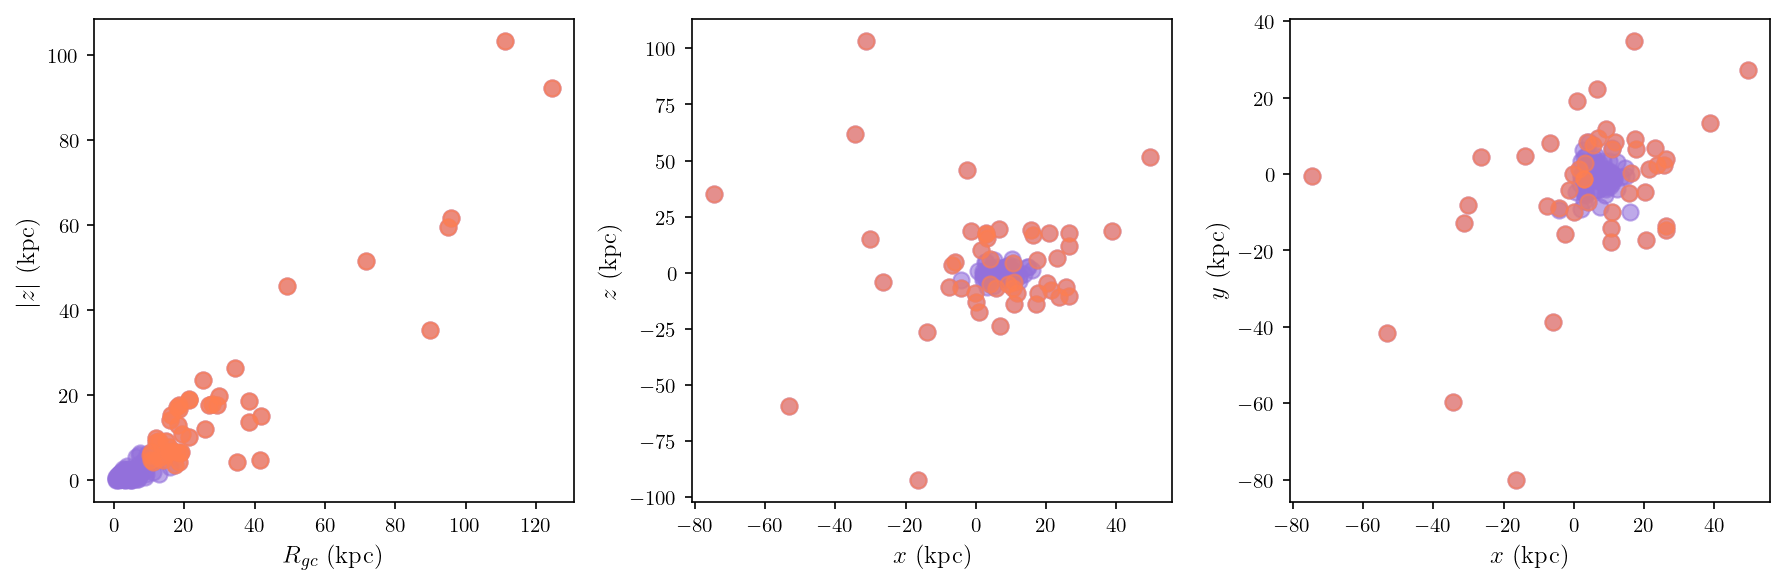

In [13]:
# Obtaining data-set and taking relevant columns


# Identification of accreted clusters
mask = (R > 10) & (abs(Z) > 3)
accreted = harris[mask]
#print("Accreted clusters (R_gc > 10 and |Z| > 3):")
#print(accreted[["ID", "R_gc", "Z"]])

# Create subplots, same code as above
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# R vs |Z|
axes[0].scatter(R, abs(Z), c='mediumpurple', alpha=0.6, s=60)
axes[0].scatter(accreted["R_gc"], abs(accreted["Z"]), c='coral', alpha=0.7, s=60)
axes[0].set_xlabel(r"$R_{gc}$ (kpc)", fontsize=12)
axes[0].set_ylabel(r"$|z|$ (kpc)", fontsize=12)

# X vs Z
axes[1].scatter(X, Z, c='mediumpurple', alpha=0.6, s=60)
axes[1].scatter(accreted["X"], accreted["Z"], c='coral', alpha=0.6, s=60)
axes[1].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[1].set_ylabel(r"$z$ (kpc)", fontsize=12)

# X vs Y
axes[2].scatter(X, Y, c='mediumpurple', alpha=0.6, s=60)
axes[2].scatter(accreted["X"], accreted["Y"], c='coral', alpha=0.6, s=60)
axes[2].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[2].set_ylabel(r"$y$ (kpc)", fontsize=12)

plt.tight_layout()
plt.show()

## Age-metallicity Relation

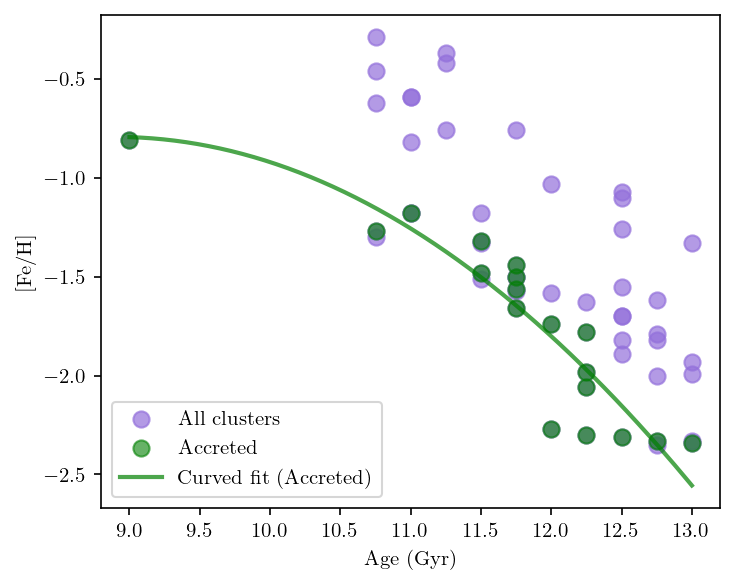

In [16]:
# Identify accreted clusters
mask = (harris["R_gc"] > 10) & (abs(harris["Z"]) > 3)
accreted_names = harris.loc[mask, "ID"]

# Find those names vandenBerg dataset
vberg_mask  = vberg["Name"].isin(accreted_names)

# Search through age-metallicity data for clusters that were identified as accreted above
feh_acc = feh_v[vberg_mask]
ages_acc = ages_v[vberg_mask]

# Defined polynomial fit
coeffs = np.polyfit(ages_acc, feh_acc, 2)
a, b, c = coeffs

# Curve fitting
x_fit = np.linspace(min(ages_acc), max(ages_acc), 200)  # Age range
y_fit = a * x_fit**2 + b * x_fit + c                   # [Fe/H] fit

# Plot
plt.figure(figsize=(5,4))

# All clusters (no longer including Krause21)
plt.scatter(ages_v, feh_v, c='mediumpurple', alpha=0.7, s=60, label="All clusters")

# Accreted clusters
plt.scatter(ages_acc, feh_acc, c='green', alpha=0.6, s=60, label="Accreted")

# Curved best-fit line
plt.plot(x_fit, y_fit, color='green', alpha=0.7, linewidth=2, label="Curved fit (Accreted)")

plt.xlabel("Age (Gyr)")
plt.ylabel("[Fe/H]")
plt.legend()
plt.tight_layout()
plt.show()

- Dwarf galaxies are the main sources of accreted globular clusters in the Milky Way.

- Their low metallicity arises from supernova-driven gas loss, as shallow gravitational potentials allow enriched material to escape easily.

- The curved age–metallicity relation (AMR) in Figure 1 reflects gradual chemical enrichment: later generations form from gas increasingly enriched in heavy elements.

- In-situ clusters formed within the Milky Way show systematically higher 
[Fe/H]
[Fe/H] at similar ages due to stronger gravitational retention of metals and more efficient star formation.

- Both accreted and in-situ populations follow the same physical trend of increasing 
[Fe/H] with time, but differ in enrichment rate and metallicity scale because of their distinct formation environments.